In [4]:
# =========================================================
# 1. Bibliotecas
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [5]:
# =========================================================
# 2. Acessa as bases do projeto
# =========================================================

base_path = r"C:\Users\Eliakim\Downloads\olist_project"

print("Bases disponíveis:", os.listdir(base_path))

orders = pd.read_csv(os.path.join(base_path, "olist_orders_dataset.csv"))
items = pd.read_csv(os.path.join(base_path, "olist_order_items_dataset.csv"))
customers = pd.read_csv(os.path.join(base_path, "olist_customers_dataset.csv"))
payments = pd.read_csv(os.path.join(base_path, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(base_path, "olist_order_reviews_dataset.csv"))
products = pd.read_csv(os.path.join(base_path, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(base_path, "olist_sellers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(base_path, "olist_geolocation_dataset.csv"))
translation = pd.read_csv(os.path.join(base_path, "product_category_name_translation.csv"))

print("Orders:", orders.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Translation:", translation.shape)

Bases disponíveis: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']
Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Geolocation: (1000163, 5)
Translation: (71, 2)


In [6]:
# =========================================================
# 3. Tratamento das datas (Conversão de string para Datetime)
# =========================================================

date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")

In [7]:
# =========================================================
# 4. Mantém pedidos entregues para evitar distorção em entrega/recência
# =========================================================

orders_validos = orders[orders["order_status"] == "delivered"].copy()

print("Pedidos válidos:", orders_validos.shape)

Pedidos válidos: (96478, 8)


In [8]:
# =========================================================
# 5. Tradução e padronização de categorias
# =========================================================

products = products.merge(
    translation,
    how="left",
    on="product_category_name"
)

products["product_category_name_english"] = products["product_category_name_english"].fillna("unknown")

In [9]:
# =========================================================
# 6. Cria as macrocategorias
# =========================================================

mapa_macro = {
    "bed_bath_table": "casa",
    "furniture_decor": "casa",
    "housewares": "casa",
    "home_confort": "casa",
    "home_appliances": "casa",
    "home_appliances_2": "casa",
    "construction_tools_construction": "casa_construcao",
    "construction_tools_lights": "casa_construcao",
    "construction_tools_safety": "casa_construcao",
    "construction_tools_tools": "casa_construcao",
    "construction_tools_garden": "casa_construcao",
    "garden_tools": "casa_construcao",
    "sports_leisure": "esporte_lazer",
    "watches_gifts": "moda_acessorios",
    "fashion_bags_accessories": "moda_acessorios",
    "fashion_shoes": "moda_acessorios",
    "fashion_underwear_beach": "moda_acessorios",
    "fashion_male_clothing": "moda_acessorios",
    "fashion_female_clothing": "moda_acessorios",
    "health_beauty": "beleza_saude",
    "perfumery": "beleza_saude",
    "telephony": "eletronicos",
    "computers_accessories": "eletronicos",
    "electronics": "eletronicos",
    "computers": "eletronicos",
    "tablets_printing_image": "eletronicos",
    "audio": "eletronicos",
    "fixed_telephony": "eletronicos",
    "cool_stuff": "variedades",
    "toys": "variedades",
    "stationery": "variedades",
    "baby": "infantil",
    "books_general_interest": "cultura",
    "books_technical": "cultura",
    "books_imported": "cultura",
    "music": "cultura",
    "cds_dvds_musicals": "cultura",
    "dvds_blu_ray": "cultura",
    "pet_shop": "pet",
    "auto": "automotivo",
    "office_furniture": "escritorio",
    "office_supplies": "escritorio",
    "small_appliances": "eletroportateis",
    "small_appliances_home_oven_and_coffee": "eletroportateis"
}

products["macro_categoria"] = products["product_category_name_english"].map(mapa_macro)
products["macro_categoria"] = products["macro_categoria"].fillna("outros")

In [10]:
# =========================================================
# 7. Merges para criação da base consolidada transacional, contendo as informações principais de cada compra
# =========================================================

df = orders_validos.merge(customers, on="customer_id", how="left")
df = df.merge(items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(reviews[["order_id", "review_score"]], on="order_id", how="left")

print(df.shape)
df.head()

(115723, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,macro_categoria,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,casa,1.0,credit_card,1.0,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,casa,3.0,voucher,1.0,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,casa,2.0,voucher,1.0,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,beleza_saude,1.0,boleto,1.0,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,automotivo,1.0,credit_card,3.0,179.12,5.0


In [11]:
# =========================================================
# 8. Agregação por pedido, retirando duplicidade de item por pedido
# =========================================================

pedido_agg = df.groupby(["customer_unique_id", "order_id"], as_index=False).agg(
    data_compra=("order_purchase_timestamp", "max"),
    valor_pedido=("payment_value", "sum"),
    review_score=("review_score", "mean"),
    data_entrega=("order_delivered_customer_date", "max"),
    data_estimada=("order_estimated_delivery_date", "max")
)

pedido_agg["tempo_entrega_dias"] = (
    pedido_agg["data_entrega"] - pedido_agg["data_compra"]
).dt.days

In [12]:
# =========================================================
# 9. Consolidação da base na visão cliente: variáveis RFM + complementares
# =========================================================

data_referencia = pedido_agg["data_compra"].max() + pd.Timedelta(days=1)

df_cliente = pedido_agg.groupby("customer_unique_id", as_index=False).agg(
    ultima_compra=("data_compra", "max"),
    frequencia=("order_id", "nunique"),
    valor=("valor_pedido", "sum"),
    media_review=("review_score", "mean"),
    tempo_entrega_medio=("tempo_entrega_dias", "mean")
)

df_cliente["recencia_dias"] = (data_referencia - df_cliente["ultima_compra"]).dt.days
df_cliente["ticket_medio"] = df_cliente["valor"] / df_cliente["frequencia"]

# Variáveis extras
primeira_compra = pedido_agg.groupby("customer_unique_id", as_index=False)["data_compra"].min()
primeira_compra.columns = ["customer_unique_id", "primeira_compra"]

df_cliente = df_cliente.merge(primeira_compra, on="customer_unique_id", how="left")

df_cliente["tempo_atividade"] = (
    df_cliente["ultima_compra"] - df_cliente["primeira_compra"]
).dt.days

df_cliente["freq_mensal"] = np.where(
    df_cliente["tempo_atividade"] > 0,
    df_cliente["frequencia"] / (df_cliente["tempo_atividade"] / 30),
    df_cliente["frequencia"]
)

df_cliente.head()

,customer_unique_id,ultima_compra,frequencia,valor,media_review,tempo_entrega_medio,recencia_dias,ticket_medio,primeira_compra,tempo_atividade,freq_mensal
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,5.0,6.0,112,141.90,2018-05-10 10:56:27,0,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,4.0,3.0,115,27.19,2018-05-07 11:11:27,0,1.0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,3.0,25.0,537,86.22,2017-03-10 21:05:03,0,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,4.0,20.0,321,43.62,2017-10-12 20:29:41,0,1.0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,5.0,13.0,288,196.89,2017-11-14 19:45:42,0,1.0


In [13]:
# =========================================================
# 10. Categoria predominante por cliente
# =========================================================

cliente_categoria = df.groupby(["customer_unique_id", "macro_categoria"], as_index=False).agg(
    qtd_itens=("order_item_id", "count")
)

cliente_categoria = cliente_categoria.sort_values(
    ["customer_unique_id", "qtd_itens"],
    ascending=[True, False]
)

categoria_predominante = cliente_categoria.drop_duplicates("customer_unique_id")
categoria_predominante = categoria_predominante[["customer_unique_id", "macro_categoria"]]
categoria_predominante.columns = ["customer_unique_id", "categoria_predominante"]

df_cliente = df_cliente.merge(categoria_predominante, on="customer_unique_id", how="left")
df_cliente["categoria_predominante"] = df_cliente["categoria_predominante"].fillna("outros")

In [14]:
# =========================================================
# 11. Tratamento de nulos e outliers
# =========================================================

colunas_numericas = [
    "recencia_dias",
    "frequencia",
    "valor",
    "ticket_medio",
    "tempo_entrega_medio",
    "media_review"
]

for col in colunas_numericas:
    df_cliente[col] = df_cliente[col].replace([np.inf, -np.inf], np.nan)
    df_cliente[col] = df_cliente[col].fillna(df_cliente[col].median())

# Winsorização simples para reduzir distorções extremas
for col in ["valor", "ticket_medio", "tempo_entrega_medio"]:
    p1 = df_cliente[col].quantile(0.01)
    p99 = df_cliente[col].quantile(0.99)
    df_cliente[col] = df_cliente[col].clip(lower=p1, upper=p99)

In [15]:
# =========================================================
# 12. Análise descritiva
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_cliente["recencia_dias"], bins=40, ax=axes[0,0])
axes[0,0].set_title("Recência")

sns.histplot(df_cliente["frequencia"], bins=20, ax=axes[0,1])
axes[0,1].set_title("Frequência")

sns.histplot(df_cliente["ticket_medio"], bins=40, ax=axes[1,0])
axes[1,0].set_title("Ticket Médio")

sns.histplot(df_cliente["valor"], bins=40, ax=axes[1,1])
axes[1,1].set_title("Valor Total")

plt.tight_layout()
plt.savefig("figura_histogramas.png", dpi=300)
plt.close()

In [16]:
# =========================================================
# 13. Seleção de features para clusterização
# =========================================================

features_cluster = [
    "recencia_dias",
    "frequencia",
    "valor",
    "ticket_medio"
]

X = df_cliente[features_cluster].copy()
X.head()

,recencia_dias,frequencia,valor,ticket_medio
0,112,1,141.90,141.90
1,115,1,27.19,27.19
2,537,1,86.22,86.22
3,321,1,43.62,43.62
4,288,1,196.89,196.89


In [17]:
# =========================================================
# 14. Padronização das variáveis
# =========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# =========================================================
# 15. Avaliação do K-means para diferentes k
# =========================================================

resultados_kmeans = []

for k in range(2, 11):
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modelo_kmeans.fit_predict(X_scaled)

    resultados_kmeans.append({
        "k": k,
        "inercia": modelo_kmeans.inertia_,
        "silhouette": silhouette_score(X_scaled, labels_k),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels_k),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_k)
    })

df_resultados_kmeans = pd.DataFrame(resultados_kmeans)
df_resultados_kmeans

,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,2,245247.059116,0.674348,0.759414,48795.045149
1,3,172064.134230,0.696745,0.631675,54627.007262
2,4,111681.540553,0.450634,0.724249,72932.004197
3,5,85194.755850,0.474469,0.671327,78960.189833
4,6,71656.166432,0.407770,0.728593,78629.614015
5,7,61931.241291,0.409879,0.767329,78256.053790
6,8,53621.868922,0.421991,0.774569,79536.809061
7,9,48639.970096,0.427386,0.767637,77917.197419
8,10,44742.601454,0.378140,0.803273,76195.603013


In [19]:
# =========================================================
# 16. Foco em k = 4,5,6
# =========================================================

df_resultados_kmeans[df_resultados_kmeans["k"].isin([4, 5, 6])]

,k,inercia,silhouette,davies_bouldin,calinski_harabasz
2,4,111681.540553,0.450634,0.724249,72932.004197
3,5,85194.755850,0.474469,0.671327,78960.189833
4,6,71656.166432,0.407770,0.728593,78629.614015


In [20]:
# =========================================================
# 17. Elbow + Silhouette
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_resultados_kmeans["k"], df_resultados_kmeans["inercia"], marker="o")
axes[0].set_title("Método do Elbow")

axes[1].plot(df_resultados_kmeans["k"], df_resultados_kmeans["silhouette"], marker="o")
axes[1].set_title("Silhouette Score")

plt.tight_layout()
plt.savefig("figura_elbow_silhouette.png", dpi=300)
plt.close()

In [21]:
# =========================================================
# 18. K-means final
# =========================================================

k_final = 6

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

df_cliente["cluster"] = labels_kmeans

In [36]:
# =========================================================
# 19. Volume dos clusters (com nomes)
# =========================================================

# Mapeamento dos clusters
mapa_clusters = {
    0: "Aquisição Recente",
    1: "Alto Impacto Pontual",
    2: "Inatividade Prolongada",
    3: "Consumo Residual",
    4: "Recorrência Diluída",
    5: "Valor Moderado Pontual"
}

# Criar coluna com nome dos clusters
df_cliente["cluster_nome"] = df_cliente["cluster"].map(mapa_clusters)

# Ordem lógica dos clusters
ordem_clusters = [
    "Aquisição Recente",
    "Alto Impacto Pontual",
    "Inatividade Prolongada",
    "Consumo Residual",
    "Recorrência Diluída",
    "Valor Moderado Pontual"
]

# Calcular volume
volume_clusters = (
    df_cliente["cluster_nome"]
    .value_counts()
    .reindex(ordem_clusters)
    .reset_index()
)

volume_clusters.columns = ["cluster_nome", "qtd_clientes"]

# Percentual
volume_clusters["perc_clientes"] = (
    volume_clusters["qtd_clientes"] / volume_clusters["qtd_clientes"].sum() * 100
).round(2)

# Exibir resultado
print("Volume dos clusters:")
print(volume_clusters)

Volume dos clusters:
             cluster_nome  qtd_clientes  perc_clientes
0       Aquisição Recente         31265          33.49
1    Alto Impacto Pontual          2192           2.35
2  Inatividade Prolongada         19442          20.83
3        Consumo Residual         30436          32.60
4     Recorrência Diluída          2721           2.91
5  Valor Moderado Pontual          7302           7.82


In [37]:
# =========================================================
# 20. Perfil médio dos clusters
# =========================================================

perfil_clusters = df_cliente.groupby("cluster")[features_cluster].mean().round(2)
perfil_clusters

,recencia_dias,frequencia,valor,ticket_medio
cluster,,,,
0,87.03,1.00,121.64,121.63
1,238.50,1.04,1441.00,1405.98
2,459.43,1.00,125.52,125.52
3,255.91,1.00,113.91,113.91
4,220.21,2.12,366.14,174.91
5,225.92,1.00,574.75,574.75


In [38]:
# =========================================================
# 21. Perfil médio + tamanho
# =========================================================

perfil_clusters_completo = perfil_clusters.copy()
perfil_clusters_completo["qtd_clientes"] = tamanho_clusters
perfil_clusters_completo["perc_clientes"] = percentual_clusters

perfil_clusters_completo = perfil_clusters_completo.sort_values(by="valor", ascending=False)
perfil_clusters_completo

,recencia_dias,frequencia,valor,ticket_medio,qtd_clientes,perc_clientes
cluster,,,,,,
1,238.50,1.04,1441.00,1405.98,2192,2.35
5,225.92,1.00,574.75,574.75,7302,7.82
4,220.21,2.12,366.14,174.91,2721,2.91
2,459.43,1.00,125.52,125.52,19442,20.83
0,87.03,1.00,121.64,121.63,31265,33.49
3,255.91,1.00,113.91,113.91,30436,32.60


In [39]:
# =========================================================
# 22. Padrão relativo dos clusters (Z-score médio)
# =========================================================

df_z = pd.DataFrame(X_scaled, columns=features_cluster)
df_z["cluster"] = df_cliente["cluster"].values

perfil_z = df_z.groupby("cluster")[features_cluster].mean().round(2)
perfil_z

,recencia_dias,frequencia,valor,ticket_medio
cluster,,,,
0,-0.99,-0.16,-0.28,-0.27
1,0.00,0.01,4.87,4.96
2,1.45,-0.16,-0.27,-0.25
3,0.12,-0.16,-0.31,-0.30
4,-0.12,5.18,0.67,-0.05
5,-0.08,-0.16,1.49,1.58


In [40]:
# =========================================================
# 23. Heatmap dos clusters
# =========================================================

plt.figure(figsize=(10,6))
sns.heatmap(perfil_z, annot=True, cmap="coolwarm", center=0)
plt.title("Perfil padronizado dos clusters")
plt.savefig("figura_heatmap_clusters.png", dpi=300)
plt.close()

In [41]:
# =========================================================
# 24. Boxplots por cluster
# =========================================================

mapa_clusters = {
    0: "Aquisição Recente",
    1: "Alto Impacto Pontual",
    2: "Inatividade Prolongada",
    3: "Consumo Residual",
    4: "Recorrência Dilúida",
    5: "Valor Moderado Pontual"
}

df_cliente["cluster_nome"] = df_cliente["cluster"].map(mapa_clusters)

ordem_clusters = [
    "Aquisição Recente",
    "Alto Impacto Pontual",
    "Inatividade Prolongada",
    "Consumo Residual",
    "Recorrência Dilúida",
    "Valor Moderado Pontual"
]



import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=df_cliente, x="cluster_nome", y="recencia_dias", order=ordem_clusters, ax=axes[0,0])
axes[0,0].set_title("Recência por cluster")
axes[0,0].set_xlabel("")
axes[0,0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df_cliente, x="cluster_nome", y="frequencia", order=ordem_clusters, ax=axes[0,1])
axes[0,1].set_title("Frequência por cluster")
axes[0,1].set_xlabel("")
axes[0,1].tick_params(axis='x', rotation=20)

sns.boxplot(data=df_cliente, x="cluster_nome", y="valor", order=ordem_clusters, ax=axes[1,0])
axes[1,0].set_title("Valor total por cluster")
axes[1,0].set_xlabel("")
axes[1,0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df_cliente, x="cluster_nome", y="ticket_medio", order=ordem_clusters, ax=axes[1,1])
axes[1,1].set_title("Ticket médio por cluster")
axes[1,1].set_xlabel("")
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("figura_boxplots_clusters_nomeados.png", dpi=300, bbox_inches="tight")
plt.close()

In [56]:
# =========================================================
# 25. Categoria predominando por cluster
# =========================================================

top_categorias_cluster = (
    df_cliente.groupby(["cluster_nome", "categoria_predominante"])
    .size()
    .reset_index(name="qtd")
)

top_categorias_cluster["rank"] = (
    top_categorias_cluster.groupby("cluster_nome")["qtd"]
    .rank(method="first", ascending=False)
)

top3_categorias_cluster = top_categorias_cluster[top_categorias_cluster["rank"] <= 3].copy()
top3_categorias_cluster = top3_categorias_cluster.sort_values(["cluster_nome", "qtd"], ascending=[True, False])

# plt.figure(figsize=(10,6))
# sns.barplot(data=top3_categorias_cluster, x="cluster_nome", y="qtd", hue="categoria_predominante")
# plt.title("Categorias predominantes por cluster")
# plt.savefig("figura_categorias_cluster.png", dpi=300)
# plt.close()

plt.figure(figsize=(12,7))

sns.barplot(
    data=top3_categorias_cluster,
    y="cluster_nome",   # eixo vertical
    x="qtd",
    hue="categoria_predominante",
    order=ordem_clusters
)

plt.title("Categorias predominantes por cluster")
plt.ylabel("")
plt.xlabel("Quantidade")

plt.legend(title="Categoria", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("figura_categorias_cluster.png", dpi=300, bbox_inches="tight")
plt.close()

In [29]:
# =========================================================
# 26. GMM - Teste de k
# =========================================================

resultados_gmm = []

for k in range(2, 11):
    modelo_gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    labels_gmm = modelo_gmm.fit_predict(X_scaled)

    # Garantia mínima para cálculo
    if len(np.unique(labels_gmm)) > 1:
        resultados_gmm.append({
            "k": k,
            "silhouette": silhouette_score(X_scaled, labels_gmm),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels_gmm),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_gmm),
            "bic": modelo_gmm.bic(X_scaled),
            "aic": modelo_gmm.aic(X_scaled)
        })

df_resultados_gmm = pd.DataFrame(resultados_gmm)
df_resultados_gmm

,k,silhouette,davies_bouldin,calinski_harabasz,bic,aic
0,2,0.722001,1.200594,31357.865304,-1.539635e+06,-1.539909e+06
1,3,0.456406,1.295340,31134.242256,-1.638564e+06,-1.638979e+06
2,4,0.446703,0.832550,38949.812798,-1.664929e+06,-1.665487e+06
3,5,0.452130,0.999982,31833.670769,-1.745032e+06,-1.745731e+06
4,6,0.434493,0.901026,48739.341827,-1.753192e+06,-1.754032e+06
5,7,0.184085,1.024535,39461.705647,-1.768398e+06,-1.769380e+06
6,8,0.304099,0.978436,50286.985353,-1.771922e+06,-1.773046e+06
7,9,0.296498,0.983023,47574.530363,-1.775753e+06,-1.777018e+06
8,10,0.172195,1.115692,39925.769326,-1.781341e+06,-1.782748e+06


In [30]:
# =========================================================
# 27. GMM final (k = 6 para comparação com K-means)
# =========================================================

gmm_final = GaussianMixture(
    n_components=6,
    covariance_type="full",
    random_state=42
)

labels_gmm_final = gmm_final.fit_predict(X_scaled)

print("Silhouette GMM:", silhouette_score(X_scaled, labels_gmm_final))
print("Davies-Bouldin GMM:", davies_bouldin_score(X_scaled, labels_gmm_final))
print("Calinski-Harabasz GMM:", calinski_harabasz_score(X_scaled, labels_gmm_final))

Silhouette GMM: 0.4344929267705271
Davies-Bouldin GMM: 0.9010263265374947
Calinski-Harabasz GMM: 48739.34182708787


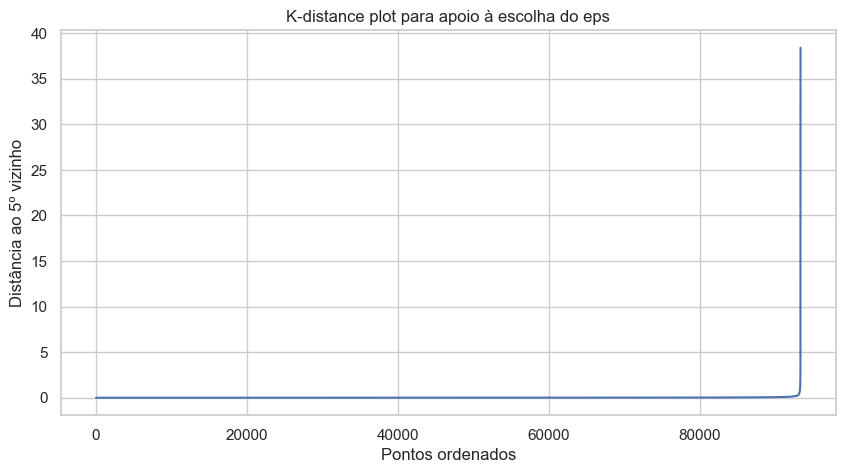

In [31]:
# =========================================================
# 28. DBSCAN - K-distande plot
# =========================================================

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("K-distance plot para apoio à escolha do eps")
plt.xlabel("Pontos ordenados")
plt.ylabel("Distância ao 5º vizinho")
plt.show()

In [32]:
# =========================================================
# 29. DBSCAN (Teste em amostra)
# =========================================================

from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

# tamanho da amostra
n_amostra = min(20000, len(X_scaled))

np.random.seed(42)
idx_amostra = np.random.choice(len(X_scaled), size=n_amostra, replace=False)
X_sample = X_scaled[idx_amostra]

resultados_dbscan = []

for eps in [0.3, 0.5, 0.7, 0.9, 1.1]:
    try:
        modelo_dbscan = DBSCAN(eps=eps, min_samples=5, n_jobs=-1)
        labels_db = modelo_dbscan.fit_predict(X_sample)

        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_ruido = np.sum(labels_db == -1)

        if n_clusters > 1:
            mask = labels_db != -1
            resultados_dbscan.append({
                "eps": eps,
                "n_clusters": n_clusters,
                "n_ruido": int(n_ruido),
                "perc_ruido": round(n_ruido / len(labels_db) * 100, 2),
                "silhouette": silhouette_score(X_sample[mask], labels_db[mask]),
                "davies_bouldin": davies_bouldin_score(X_sample[mask], labels_db[mask]),
                "calinski_harabasz": calinski_harabasz_score(X_sample[mask], labels_db[mask])
            })
        else:
            resultados_dbscan.append({
                "eps": eps,
                "n_clusters": n_clusters,
                "n_ruido": int(n_ruido),
                "perc_ruido": round(n_ruido / len(labels_db) * 100, 2),
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan
            })

    except MemoryError:
        resultados_dbscan.append({
            "eps": eps,
            "n_clusters": np.nan,
            "n_ruido": np.nan,
            "perc_ruido": np.nan,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        })

df_resultados_dbscan = pd.DataFrame(resultados_dbscan)
df_resultados_dbscan

,eps,n_clusters,n_ruido,perc_ruido,silhouette,davies_bouldin,calinski_harabasz
0,0.3,9,129,0.64,0.363432,0.504903,537.240397
1,0.5,4,81,0.40,0.382883,0.521278,1379.733222
2,0.7,4,39,0.19,0.652809,0.475111,1592.221851
3,0.9,5,29,0.14,0.651620,0.452315,1260.013283
4,1.1,4,23,0.12,0.655893,0.479459,1675.616864


In [33]:
# =========================================================
# 30. DBSCAN final em amostra
# =========================================================

dbscan_final = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1)
labels_dbscan = dbscan_final.fit_predict(X_sample)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido_dbscan = np.sum(labels_dbscan == -1)

print("Clusters DBSCAN:", n_clusters_dbscan)
print("Pontos classificados como ruído:", n_ruido_dbscan)
print("Percentual de ruído:", round(n_ruido_dbscan / len(labels_dbscan) * 100, 2), "%")

Clusters DBSCAN: 4
Pontos classificados como ruído: 81
Percentual de ruído: 0.4 %


In [34]:
# =========================================================
# 31. Comparação final dos modelos
# =========================================================

comparacao_modelos = []

# KMeans final
comparacao_modelos.append({
    "metodo": "K-Means",
    "n_clusters": len(np.unique(labels_kmeans)),
    "silhouette": silhouette_score(X_scaled, labels_kmeans),
    "davies_bouldin": davies_bouldin_score(X_scaled, labels_kmeans),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_kmeans)
})

# GMM final
comparacao_modelos.append({
    "metodo": "GMM",
    "n_clusters": len(np.unique(labels_gmm_final)),
    "silhouette": silhouette_score(X_scaled, labels_gmm_final),
    "davies_bouldin": davies_bouldin_score(X_scaled, labels_gmm_final),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_gmm_final)
})

# DBSCAN final em amostra
if n_clusters_dbscan > 1:
    mask_db = labels_dbscan != -1

    # só calcula se restarem pontos suficientes sem ruído
    if mask_db.sum() > 1 and len(np.unique(labels_dbscan[mask_db])) > 1:
        comparacao_modelos.append({
            "metodo": "DBSCAN",
            "n_clusters": n_clusters_dbscan,
            "silhouette": silhouette_score(X_sample[mask_db], labels_dbscan[mask_db]),
            "davies_bouldin": davies_bouldin_score(X_sample[mask_db], labels_dbscan[mask_db]),
            "calinski_harabasz": calinski_harabasz_score(X_sample[mask_db], labels_dbscan[mask_db])
        })
    else:
        comparacao_modelos.append({
            "metodo": "DBSCAN",
            "n_clusters": n_clusters_dbscan,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        })
else:
    comparacao_modelos.append({
        "metodo": "DBSCAN",
        "n_clusters": n_clusters_dbscan,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan
    })

df_comparacao_modelos = pd.DataFrame(comparacao_modelos)
df_comparacao_modelos

,metodo,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,6,0.407770,0.728593,78629.614015
1,GMM,6,0.434493,0.901026,48739.341827
2,DBSCAN,4,0.382883,0.521278,1379.733222


In [35]:
# =========================================================
# 32. Exportação das tabelas
# =========================================================

perfil_clusters_completo.to_csv("perfil_clusters_completo.csv", index=True)
top3_categorias_cluster.to_csv("top3_categorias_cluster.csv", index=False)
df_comparacao_modelos.to_csv("comparacao_modelos.csv", index=False)

In [44]:
# =========================================================
# 33. Categorias originais
# =========================================================

categorias_originais = (
    df.groupby("product_category_name")
    .size()
    .reset_index(name="qtd")
    .sort_values(by="qtd", ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=categorias_originais.head(10),
    x="qtd",
    y="product_category_name"
)

plt.title("Top 10 categorias de produtos (original)")
plt.xlabel("Quantidade")
plt.ylabel("Categoria")

plt.tight_layout()
plt.savefig("figura_categorias_top10.png", dpi=300, bbox_inches="tight")
plt.close()

In [48]:
# =========================================================
# 34. Pareto categorias originais
# =========================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

categorias_originais = (
    df.groupby("product_category_name")
    .size()
    .reset_index(name="qtd")
    .sort_values(by="qtd", ascending=False)
)

categorias_originais["perc"] = categorias_originais["qtd"] / categorias_originais["qtd"].sum()
categorias_originais["perc_acum"] = categorias_originais["perc"].cumsum()

fig, ax1 = plt.subplots(figsize=(18, 8))

# Barras
ax1.bar(categorias_originais["product_category_name"], categorias_originais["qtd"])
ax1.set_title("Curva de Pareto - Categorias originais")
ax1.set_xlabel("Categorias")
ax1.set_ylabel("Quantidade")
ax1.grid(False)

# Rotação dos rótulos
ax1.tick_params(axis="x", rotation=90, labelsize=7)

# Linha acumulada
ax2 = ax1.twinx()
ax2.plot(
    categorias_originais["product_category_name"],
    categorias_originais["perc_acum"] * 100,
    color="red",
    marker="o",
    markersize=2,
    linewidth=1.5
)

ax2.set_ylabel("Percentual acumulado (%)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax2.grid(False)

plt.tight_layout()
plt.savefig("figura_pareto_categorias_originais.png", dpi=300, bbox_inches="tight")
plt.close()

In [46]:
# =========================================================
# 35. Categorias agrupadas
# =========================================================

categorias_macro = (
    df.groupby("macro_categoria")
    .size()
    .reset_index(name="qtd")
    .sort_values(by="qtd", ascending=False)
)

In [49]:
# =========================================================
# 36. Pareto categorias agrupadas
# =========================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

categorias_macro = (
    df.groupby("macro_categoria")
    .size()
    .reset_index(name="qtd")
    .sort_values(by="qtd", ascending=False)
)

categorias_macro["perc"] = categorias_macro["qtd"] / categorias_macro["qtd"].sum()
categorias_macro["perc_acum"] = categorias_macro["perc"].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(categorias_macro["macro_categoria"], categorias_macro["qtd"])
ax1.set_title("Curva de Pareto - Macro categorias")
ax1.set_xlabel("Macro categorias")
ax1.set_ylabel("Quantidade")
ax1.grid(False)

# Ajuste do eixo X
ax1.tick_params(axis="x", rotation=35, labelsize=9)

# Linha acumulada
ax2 = ax1.twinx()
ax2.plot(
    categorias_macro["macro_categoria"],
    categorias_macro["perc_acum"] * 100,
    color="red",
    marker="o",
    linewidth=1.8
)

ax2.set_ylabel("Percentual acumulado (%)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax2.grid(False)

plt.tight_layout()
plt.savefig("figura_pareto_macro_categorias.png", dpi=300, bbox_inches="tight")
plt.close()

In [50]:
# =========================================================
# 37. Silhouette score para GMM
# =========================================================

import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

ks_gmm = range(2, 11)
silhouette_gmm = []

for k in ks_gmm:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    
    labels_gmm = gmm.fit_predict(X_scaled)
    
    # Silhouette só faz sentido se houver mais de 1 grupo
    if len(set(labels_gmm)) > 1:
        score = silhouette_score(X_scaled, labels_gmm)
    else:
        score = None
    
    silhouette_gmm.append(score)

plt.figure(figsize=(8,5))
plt.plot(list(ks_gmm), silhouette_gmm, marker="o")
plt.title("Silhouette Score para GMM")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(ks_gmm))
plt.grid(False)

plt.tight_layout()
plt.savefig("grafico_silhouette_gmm.png", dpi=300, bbox_inches="tight")
plt.close()

In [51]:
# =========================================================
# 38. Avaliação do DBSCAN - clusters e ruído por epsilon
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

eps_values = [0.2, 0.3, 0.5, 0.7, 0.9, 1.1]

n_clusters_list = []
n_noise_list = []

# Amostra
X_sample = X_scaled[:20000]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_sample)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    n_clusters_list.append(n_clusters)
    n_noise_list.append(n_noise)

# Plot
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(eps_values, n_clusters_list, marker="o", label="Número de clusters")
ax1.set_xlabel("Epsilon (ε)")
ax1.set_ylabel("Número de clusters")

ax2 = ax1.twinx()
ax2.plot(eps_values, n_noise_list, marker="s", color="red", label="Ruído (-1)")
ax2.set_ylabel("Quantidade de pontos classificados como ruído")

plt.title("Comportamento do DBSCAN para diferentes valores de ε")

plt.grid(False)
plt.tight_layout()

plt.savefig("grafico_dbscan_avaliacao.png", dpi=300, bbox_inches="tight")
plt.close()

In [53]:
import numpy as np

comparacao_modelos_final = df_comparacao_modelos.copy()

# Renomear colunas
comparacao_modelos_final = comparacao_modelos_final.rename(columns={
    "metodo": "Modelo",
    "n_clusters": "Nº de clusters",
    "silhouette": "Silhouette Score",
    "davies_bouldin": "Davies-Bouldin",
    "calinski_harabasz": "Calinski-Harabasz"
})

# Calcular ruído do DBSCAN
ruido_dbscan = round((np.sum(labels_dbscan == -1) / len(labels_dbscan)) * 100, 2)

# Criar colunas adicionais
comparacao_modelos_final["Ruído (%)"] = "-"
comparacao_modelos_final["Interpretabilidade"] = ""
comparacao_modelos_final["Adequação ao estudo"] = ""

# Preencher manualmente
comparacao_modelos_final.loc[comparacao_modelos_final["Modelo"] == "K-Means",
                             ["Interpretabilidade", "Adequação ao estudo"]] = ["Alta", "Alta"]

comparacao_modelos_final.loc[comparacao_modelos_final["Modelo"] == "GMM",
                             ["Interpretabilidade", "Adequação ao estudo"]] = ["Média", "Moderada"]

comparacao_modelos_final.loc[comparacao_modelos_final["Modelo"] == "DBSCAN",
                             ["Interpretabilidade", "Adequação ao estudo"]] = ["Baixa", "Baixa"]

comparacao_modelos_final.loc[comparacao_modelos_final["Modelo"] == "DBSCAN",
                             "Ruído (%)"] = ruido_dbscan

comparacao_modelos_final = comparacao_modelos_final.round(3)

comparacao_modelos_final

,Modelo,Nº de clusters,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Ruído (%),Interpretabilidade,Adequação ao estudo
0,K-Means,6,0.408,0.729,78629.614,-,Alta,Alta
1,GMM,6,0.434,0.901,48739.342,-,Média,Moderada
2,DBSCAN,4,0.383,0.521,1379.733,0.4,Baixa,Baixa
